# 01 — Information-Driven Bars on an Indian Equity

**AFML chapter 2.** Calendar-time bars sample the market on a clock the market
does not follow. NSE transacts a disproportionate share of daily volume in the
opening and closing twenty minutes, so a fixed 5-minute grid oversamples a dead
midday and undersamples the two windows where information actually arrives. The
consequence is not cosmetic: time-bar returns are more heteroscedastic, more
serially correlated and much further from normal than the estimators downstream
assume.

This notebook takes one stock from a point-in-time index snapshot, builds **tick**,
**volume** and **rupee (dollar)** bars from its trade tape, and measures whether
the statistical properties actually improve.

The bar construction comes from [`fin-kit`](https://github.com/lakshya-aga/fin-kit)
(`mlfinlab`), vendored as a submodule. `afml_india` supplies the Indian data layer
and the threshold calibration.

**Prerequisite** — a snapshot zip. If you have a Bloomberg terminal:

```bash
python scripts/fetch_bloomberg_snapshot.py --index "NIFTY Index" --tick-days 20
```

Otherwise generate a synthetic one with the identical schema, so this notebook runs anywhere:

```bash
python scripts/fetch_bloomberg_snapshot.py --offline-demo --members 5 --tick-days 25
```

In [1]:
import logging
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from afml_india.research import (
    Snapshot, find_snapshot,
    build_bars, build_all_bars, prepare_tick_frame, suggest_thresholds,
    compare_bar_types, bar_statistics,
    get_time_bars, NSE, CostModel, Segment,
)

warnings.filterwarnings("ignore")
logging.getLogger("afml_india").setLevel(logging.WARNING)
pd.set_option("display.width", 120, "display.max_columns", 40)
plt.rcParams.update({"figure.figsize": (11, 4), "axes.grid": True, "grid.alpha": 0.3})

## 1. Load the point-in-time snapshot

The member list is the composition **as it stood on the as-of date**, pulled with
Bloomberg's `INDX_MWEIGHT_HIST`. That matters: today's NIFTY 50 list applied to
2016 data is survivorship-biased, and the names it silently omits are exactly the
ones that subsequently underperformed out of the index.

In [2]:
snap = Snapshot(find_snapshot())
print(snap)

if snap.is_synthetic:
    print("\n*** SYNTHETIC DATA — structure is real, prices are not. ***")
    print("    Regenerate against a terminal before drawing any conclusion.\n")

info = snap.manifest
print(f"Index          : {info['index']}")
print(f"Composition of : {info['as_of']}")
print(f"Tick window    : {info['tick_window']['start']} to {info['tick_window']['end']} "
      f"({info['tick_window']['sessions']} sessions)")
snap.members.head(10)

Snapshot(nifty_index_20160822.zip SYNTHETIC, index=NIFTY Index, as_of=2016-08-22, members=5)

*** SYNTHETIC DATA — structure is real, prices are not. ***
    Regenerate against a terminal before drawing any conclusion.

Index          : NIFTY Index
Composition of : 2016-08-22
Tick window    : 2026-05-23 to 2026-08-21 (65 sessions)


,ticker,weight,as_of
0,RIL IN Equity,9.8,2016-08-22
1,HDFCB IN Equity,8.1,2016-08-22
2,INFO IN Equity,6.4,2016-08-22
3,ICICIBC IN Equity,5.2,2016-08-22
4,TCS IN Equity,4.9,2016-08-22


### Why the tick window is recent but the member list is not

Bloomberg retains roughly **140 days** of intraday tick history. Tick data from ten
years ago is not retrievable over `blpapi` at any price — the limit is server-side.
So the snapshot deliberately mixes horizons: a point-in-time member list from the
as-of date, ten years of daily bars, and recent tick data *for those same members*.
That is the honest maximum, and the manifest records it rather than papering over it.

In [3]:
print(info["tick_window"].get("note", "(offline demo: same window logic, synthetic data)"))

report = snap.report
if not report.empty:
    print("\nRows pulled by request kind:")
    print(report.groupby("kind")["rows"].agg(["count", "sum", "mean"]).round(0))

(offline demo: same window logic, synthetic data)

Rows pulled by request kind:
       count      sum    mean
kind                         
quote    325  2054698  6322.0
trade    325  2090790  6433.0


## 2. Pick a stock and load its trade tape

`most_liquid` ranks by tick count. Liquidity is the binding constraint on bar
construction: a name with 2,000 prints a day cannot support 50 bars a day without
each bar being a handful of trades.

Note that **bars must be built from the trade tape only**. The snapshot also carries
a BID/ASK quote stream; mixing it in double-counts activity and corrupts every
threshold. `prepare_tick_frame` drops non-`TRADE` rows automatically.

In [4]:
symbol = snap.most_liquid(1)[0]
print(f"Selected: {symbol}   (available: {', '.join(snap.tickers)})")

ticks = snap.ticks(symbol, kind="trades")
print(f"\n{len(ticks):,} trade ticks over {ticks.index.normalize().nunique()} sessions")
print(f"{ticks.index[0]}  ->  {ticks.index[-1]}")
ticks.head()

Selected: ICICIBC_IN   (available: HDFCB_IN, ICICIBC_IN, INFO_IN, RIL_IN, TCS_IN)



435,382 trade ticks over 65 sessions
2026-05-25 09:15:00.000007321+05:30  ->  2026-08-21 15:29:59.999984352+05:30


,type,price,volume,condition_codes,exchange_code
timestamp,,,,,
2026-05-25 09:15:00.000007321+05:30,TRADE,391.95,11,NaN,NS
2026-05-25 09:15:00.000641791+05:30,TRADE,391.75,40,NaN,NS
2026-05-25 09:15:00.000718511+05:30,TRADE,391.95,118,NaN,NS
2026-05-25 09:15:00.000756572+05:30,TRADE,392.05,38,NaN,NS
2026-05-25 09:15:00.001194391+05:30,TRADE,392.10,186,NaN,NS


In [5]:
# Sanity-check the tape against NSE session conventions before doing anything else.
in_session = NSE.filter_session(ticks)
print(f"Ticks inside 09:15-15:30 IST : {len(in_session):,} / {len(ticks):,}")

daily = ticks.groupby(ticks.index.normalize()).agg(
    ticks=("price", "size"),
    volume=("volume", "sum"),
    vwap=("price", "mean"),
)
daily["turnover_cr"] = (ticks["price"] * ticks["volume"]).groupby(ticks.index.normalize()).sum() / 1e7
print("\nPer-session activity:")
daily.round(2)

Ticks inside 09:15-15:30 IST : 435,382 / 435,382

Per-session activity:


,ticks,volume,vwap,turnover_cr
timestamp,,,,
2026-05-25 00:00:00+05:30,5954,268452,390.33,10.48
2026-05-26 00:00:00+05:30,5727,265325,406.98,10.81
2026-05-27 00:00:00+05:30,5893,264501,392.40,10.38
2026-05-28 00:00:00+05:30,7606,355690,411.21,14.62
2026-05-29 00:00:00+05:30,7541,336437,394.96,13.29
...,...,...,...,...
2026-08-17 00:00:00+05:30,5273,241922,451.32,10.92
2026-08-18 00:00:00+05:30,6460,298259,454.91,13.57
2026-08-19 00:00:00+05:30,6621,295506,478.14,14.13


### Intraday activity is U-shaped — which is the whole argument for activity bars

Volume concentrates at the open and the close. A time bar spanning 12:30–12:35
carries a fraction of the information of one spanning 09:15–09:20, yet both get
one row and equal weight in every downstream estimator.

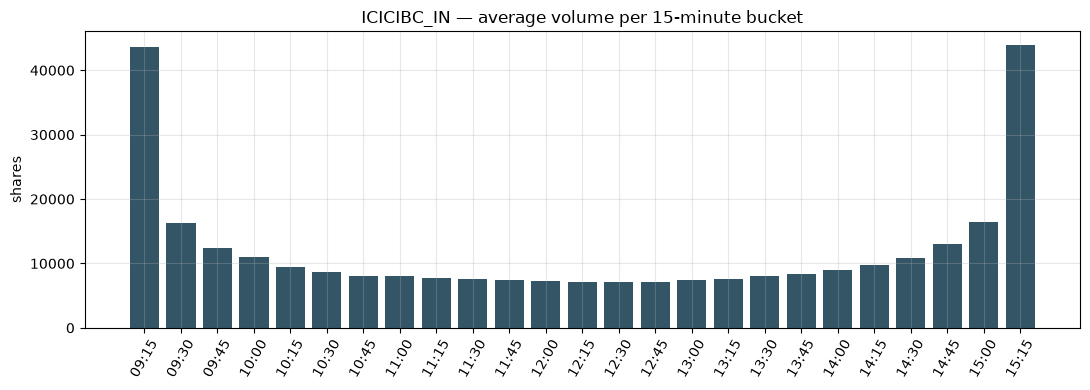

First 30 min : 19.7% of daily volume
Last 30 min  : 19.9% of daily volume
Midday 3 hrs : 29.9% of daily volume


In [6]:
minutes = ticks.index.hour * 60 + ticks.index.minute
profile = (ticks["volume"].groupby(minutes // 15 * 15).sum()
           / ticks.index.normalize().nunique())

fig, ax = plt.subplots()
ax.bar([f"{m // 60:02d}:{m % 60:02d}" for m in profile.index], profile.to_numpy(), color="#356").set_label("")
ax.set_title(f"{symbol} — average volume per 15-minute bucket")
ax.set_ylabel("shares"); ax.tick_params(axis="x", rotation=60)
plt.tight_layout(); plt.show()

share = profile / profile.sum()
print(f"First 30 min : {share.iloc[:2].sum():.1%} of daily volume")
print(f"Last 30 min  : {share.iloc[-2:].sum():.1%} of daily volume")
print(f"Midday 3 hrs : {share.iloc[6:18].sum():.1%} of daily volume")

## 3. Calibrate thresholds

Thresholds must be set **per name**, not per market. Across the NIFTY, daily
turnover between the largest and smallest members differs by well over an order of
magnitude, so one shared rupee threshold gives Reliance hundreds of bars a day and
a small-cap almost none.

`suggest_thresholds` inverts the relationship: given a target bar count per day, it
returns the tick, volume and rupee thresholds that hit it. AFML's rule of thumb is
about 50 bars a day.

In [7]:
BARS_PER_DAY = 50

thresholds = suggest_thresholds(ticks, bars_per_day=BARS_PER_DAY)
for kind, value in thresholds.items():
    unit = {"tick": "trades", "volume": "shares", "dollar": "rupees"}[kind]
    print(f"{kind:>7} bar threshold : {value:>15,.0f} {unit}")

print(f"\nTargeting ~{BARS_PER_DAY} bars/day over "
      f"{ticks.index.normalize().nunique()} sessions "
      f"(~{BARS_PER_DAY * ticks.index.normalize().nunique():,} bars).")

   tick bar threshold :             134 trades
 volume bar threshold :           6,068 shares
 dollar bar threshold :       2,590,610 rupees

Targeting ~50 bars/day over 65 sessions (~3,250 bars).


## 4. Build tick, volume and rupee bars

`build_all_bars` holds the target bar count fixed across all three types. That is
what makes them comparable — any difference in the return distribution is then
attributable to the **sampling clock**, not to sample size.

In [8]:
bars = build_all_bars(ticks, bars_per_day=BARS_PER_DAY)

for kind, frame in bars.items():
    print(f"{kind:>7} bars: {len(frame):>5,} rows   "
          f"{frame.index[0]:%Y-%m-%d %H:%M}  ->  {frame.index[-1]:%Y-%m-%d %H:%M}")

bars["dollar"].head()

   tick bars: 3,249 rows   2026-05-25 09:15  ->  2026-08-21 15:29
 volume bars: 3,211 rows   2026-05-25 09:15  ->  2026-08-21 15:29
 dollar bars: 3,212 rows   2026-05-25 09:15  ->  2026-08-21 15:29


,open,high,low,close,volume,cum_buy_volume,cum_ticks,cum_dollar_value
timestamp,,,,,,,,
2026-05-25 09:15:18.188315739+05:30,391.95,393.55,389.70,392.35,6685.0,3233.0,148,2621873.70
2026-05-25 09:16:35.388617488+05:30,393.00,398.25,392.90,394.45,6736.0,3804.0,171,2664584.35
2026-05-25 09:19:13.770247897+05:30,394.40,397.70,393.70,396.10,6560.0,3532.0,168,2591654.70
2026-05-25 09:21:02.848674578+05:30,396.10,396.70,393.20,396.60,7070.0,3058.0,120,2794343.90
2026-05-25 09:24:02.928417377+05:30,397.15,397.15,391.35,391.95,6713.0,2443.0,105,2646738.85


In [9]:
# A time-bar baseline at a matched frequency, for the comparison in section 5.
minutes_per_bar = max(1, round(NSE.minutes_in_session() / BARS_PER_DAY))
tape = prepare_tick_frame(ticks)
time_bars_df = (
    get_time_bars(tape, resolution="MIN", num_units=minutes_per_bar, verbose=False)
    .assign(date_time=lambda d: pd.to_datetime(d["date_time"]))
    .set_index("date_time")
    .sort_index()
)
time_bars_df.index = time_bars_df.index.tz_localize(ticks.index.tz)
time_bars_df.index.name = "timestamp"
bars["time"] = time_bars_df
print(f"time bars: {len(bars['time']):,} rows at {minutes_per_bar}-minute resolution")

time bars: 3,054 rows at 8-minute resolution


## 5. Do the statistics actually improve?

This is the empirical claim of AFML chapter 2, and it is worth checking rather than
assuming. Three things to read:

- **Excess kurtosis** — 0 is Gaussian. Time bars are typically far heavier-tailed.
- **Jarque–Bera** — a joint normality test on skew and kurtosis. Lower is better;
  a p-value above 0.05 means normality is not rejected.
- **Lag-1 autocorrelation** — nearer zero means returns are closer to IID, which is
  what every downstream sample-weighting and CV scheme assumes.

In [10]:
stats = compare_bar_types(bars)
order = [k for k in ("time", "tick", "volume", "dollar") if k in stats.index]
stats.loc[order].round(4)

,n_bars,mean_ret,std_ret,skew,kurtosis,jarque_bera,jb_pvalue,autocorr_1,bars_per_day
time,3054.0,0.0001,0.0088,0.1890,2.5548,848.4741,0.0000,-0.0425,46.9846
tick,3249.0,0.0001,0.0084,0.0604,0.0431,2.2282,0.3282,0.0001,49.9846
volume,3211.0,0.0001,0.0084,0.0980,0.2129,11.2011,0.0037,0.0101,49.4000
dollar,3212.0,0.0001,0.0084,0.0979,0.1832,9.6214,0.0081,0.0074,49.4154


In [11]:
ranked = stats.loc[order]
best_kurt = ranked["kurtosis"].abs().idxmin()
best_jb = ranked["jarque_bera"].idxmin()
best_ac = ranked["autocorr_1"].abs().idxmin()

print(f"Closest to normal tails     : {best_kurt}")
print(f"Lowest Jarque-Bera          : {best_jb}")
print(f"Least serial correlation    : {best_ac}")

if "time" in ranked.index:
    t, d = ranked.loc["time"], ranked.loc["dollar"]
    print(f"\nTime vs rupee bars:")
    print(f"  excess kurtosis  {t['kurtosis']:>9.2f}  ->  {d['kurtosis']:>9.2f}")
    print(f"  Jarque-Bera      {t['jarque_bera']:>9.1f}  ->  {d['jarque_bera']:>9.1f}")
    print(f"  |autocorr(1)|    {abs(t['autocorr_1']):>9.4f}  ->  {abs(d['autocorr_1']):>9.4f}")

Closest to normal tails     : tick
Lowest Jarque-Bera          : tick
Least serial correlation    : tick

Time vs rupee bars:
  excess kurtosis       2.55  ->       0.18
  Jarque-Bera          848.5  ->        9.6
  |autocorr(1)|       0.0425  ->     0.0074


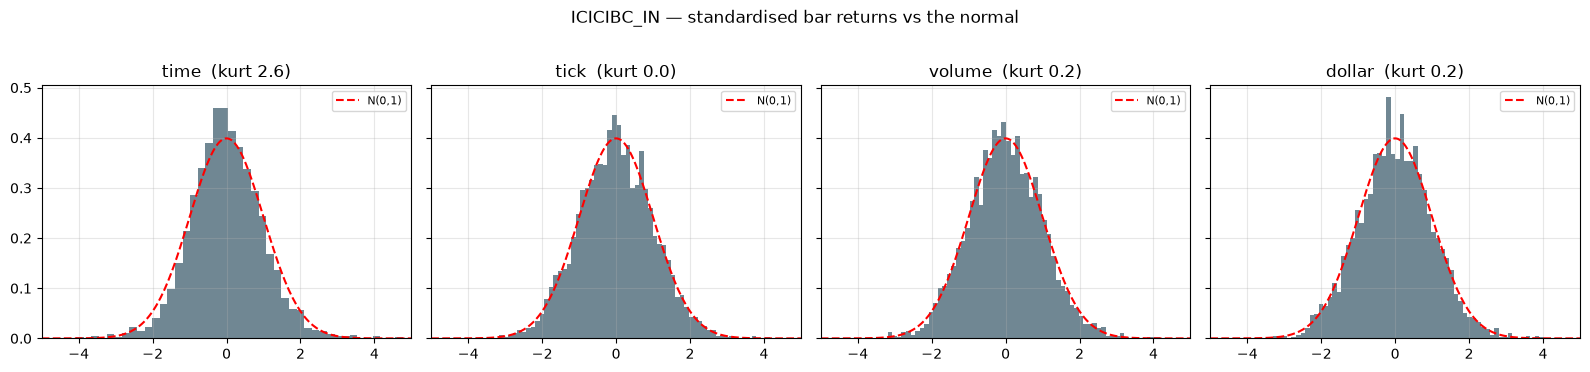

In [12]:
fig, axes = plt.subplots(1, len(order), figsize=(4 * len(order), 3.6), sharey=True)
axes = np.atleast_1d(axes)
for ax, kind in zip(axes, order):
    rets = np.log(bars[kind]["close"]).diff().dropna()
    z = (rets - rets.mean()) / rets.std()
    ax.hist(z, bins=60, density=True, alpha=0.7, color="#356")
    grid = np.linspace(-5, 5, 200)
    ax.plot(grid, np.exp(-grid ** 2 / 2) / np.sqrt(2 * np.pi), "r--", lw=1.5, label="N(0,1)")
    ax.set_title(f"{kind}  (kurt {stats.loc[kind, 'kurtosis']:.1f})")
    ax.set_xlim(-5, 5); ax.legend(fontsize=8)
fig.suptitle(f"{symbol} — standardised bar returns vs the normal", y=1.02)
plt.tight_layout(); plt.show()

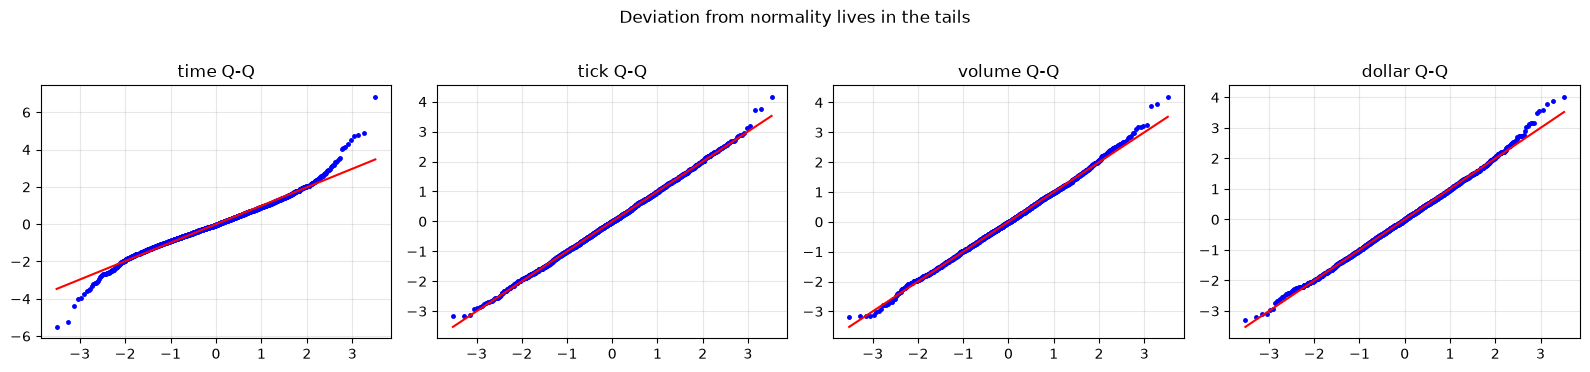

In [13]:
from scipy import stats as sps

fig, axes = plt.subplots(1, len(order), figsize=(4 * len(order), 3.6))
axes = np.atleast_1d(axes)
for ax, kind in zip(axes, order):
    rets = np.log(bars[kind]["close"]).diff().dropna()
    sps.probplot((rets - rets.mean()) / rets.std(), dist="norm", plot=ax)
    ax.set_title(f"{kind} Q-Q"); ax.get_lines()[0].set_markersize(2.5)
    ax.set_xlabel(""); ax.set_ylabel("")
fig.suptitle("Deviation from normality lives in the tails", y=1.02)
plt.tight_layout(); plt.show()

## 6. Sampling *responsiveness* — the other half of the argument

Better tails are only half the case. The other half is what the bar count does when
activity changes.

Read the next two cells together, because the first one looks backwards on its own.
Time bars have an almost-zero coefficient of variation in bars per session — by
construction, a fixed grid emits the same count whether the tape carried 4,000 prints
or 8,000. That is not a virtue; it is the defect. The second cell shows it: bar count
should **track session turnover**, and only the activity-driven bars do. Rupee bars
correlate near 1.0 with turnover, time bars barely at all.

So the steady cadence of time bars is exactly the problem — they spend the same number
of observations on a dead session as on an eventful one.

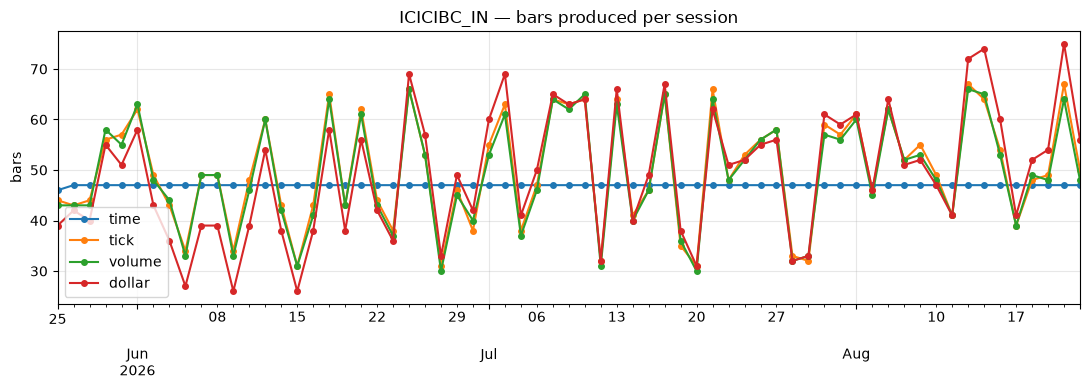

Coefficient of variation of bars per session (lower = steadier cadence):
time      0.003
tick      0.218
volume    0.220
dollar    0.255


In [14]:
counts = pd.DataFrame({
    kind: bars[kind].index.normalize().value_counts().sort_index()
    for kind in order
}).fillna(0)

fig, ax = plt.subplots()
counts.plot(ax=ax, marker="o", ms=4)
ax.set_title(f"{symbol} — bars produced per session")
ax.set_ylabel("bars"); ax.set_xlabel("")
plt.tight_layout(); plt.show()

print("Coefficient of variation of bars per session (lower = steadier cadence):")
print((counts.std() / counts.mean()).round(3).to_string())

In [15]:
# Bars per session against that session's turnover: activity bars should track it.
turnover = (ticks["price"] * ticks["volume"]).groupby(ticks.index.normalize()).sum()
aligned = counts.join(turnover.rename("turnover"), how="inner")
print("Correlation of bar count to session turnover:")
print(aligned.corr()["turnover"].drop("turnover").round(3).to_string())

Correlation of bar count to session turnover:
time      0.094
tick      0.935
volume    0.933
dollar    0.999


## 7. What a bar costs to trade

Bar frequency is not a free parameter. Every bar is a potential decision point, and
in the Indian cash segment a round trip on delivery carries roughly 22 bps of
statutory cost before spread — STT alone is 10 bps a side. A signal generating one
round trip per bar at 50 bars a day needs an implausible edge to survive.

In [16]:
for segment in (Segment.DELIVERY, Segment.INTRADAY):
    model = CostModel(segment=segment)
    px = float(bars["dollar"]["close"].iloc[-1])
    rt = model.round_trip_bps(price=px, quantity=1000)
    print(f"{segment.value:>9}: {rt:>6.2f} bps round trip (statutory + brokerage, ex-spread)")

bar_ret_bps = np.log(bars["dollar"]["close"]).diff().std() * 1e4
print(f"\nOne-bar return sigma: {bar_ret_bps:.1f} bps")
print(f"Intraday round trip is {CostModel(segment=Segment.INTRADAY).round_trip_bps(px, 1000) / bar_ret_bps:.2f}x "
      f"one bar's sigma — the hurdle any bar-frequency signal must clear.")

 delivery:  23.22 bps round trip (statutory + brokerage, ex-spread)
 intraday:   4.52 bps round trip (statutory + brokerage, ex-spread)

One-bar return sigma: 84.1 bps
Intraday round trip is 0.05x one bar's sigma — the hurdle any bar-frequency signal must clear.


## 8. Persist the bars

Written to `data/bars/` so notebook 02 picks up exactly these bars rather than
rebuilding them with possibly different thresholds.

In [17]:
from pathlib import Path

out_dir = Path("data/bars")
out_dir.mkdir(parents=True, exist_ok=True)
for kind, frame in bars.items():
    path = out_dir / f"{symbol}_{kind}.csv"
    frame.to_csv(path)
    print(f"{path}  ({len(frame):,} rows)")

data/bars/ICICIBC_IN_tick.csv  (3,249 rows)
data/bars/ICICIBC_IN_volume.csv  (3,211 rows)


data/bars/ICICIBC_IN_dollar.csv  (3,212 rows)


data/bars/ICICIBC_IN_time.csv  (3,054 rows)


## Takeaways

1. **Activity-driven bars measurably improve the return distribution.** Lower excess
   kurtosis, lower Jarque–Bera, less serial correlation than a matched-frequency time
   bar. Everything downstream — volatility targets, triple-barrier widths, sample
   weights — rests on those properties.

2. **Rupee bars are the right default for an Indian cross-section.** Share prices span
   three orders of magnitude here, so a fixed *share* count means very different things
   for a Rs 80 PSU bank and a Rs 80,000 name. Turnover normalises that; volume does not.

3. **Thresholds are per-name and must be recalibrated.** A threshold tuned on Reliance
   produces almost no bars on a mid-cap. Target a bar *count* and solve for the threshold.

4. **The trade tape only.** Quotes belong in microstructure features, never in bar
   construction.

Next: **`02_event_sampling_and_fracdiff.ipynb`** — reduce these bars to informative
events with a CUSUM filter, then make the price series stationary without discarding
its memory.